In [203]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.decomposition import PCA, SparsePCA, FactorAnalysis
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, regularizers

In [3]:
tf.random.set_seed(0)
np.random.seed(0)

# Preparação dos Dados

## Dados

- Fonte: https://www.kaggle.com/datasets/brynja/wineuci

In [4]:
cols = [
    'class','alcohol','malic_acid','ash','alcalinity_of_ash','magnesium','total_phenols','flavanoids',
    'nonflavanoid_phenols','proanthocyanins','color_intensity','hue','od280_od315','proline'
]
data = pd.read_csv("C:/Users/aless/Downloads/Wine.csv", header=None, names=cols)
data['class'] = data['class'].astype(str)

features = data.iloc[:,1:]
X_scaled = features.sub(features.mean()).div(features.std())
data.shape

(178, 14)

In [5]:
data.head()

,class,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280_od315,proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   class                 178 non-null    object 
 1   alcohol               178 non-null    float64
 2   malic_acid            178 non-null    float64
 3   ash                   178 non-null    float64
 4   alcalinity_of_ash     178 non-null    float64
 5   magnesium             178 non-null    int64  
 6   total_phenols         178 non-null    float64
 7   flavanoids            178 non-null    float64
 8   nonflavanoid_phenols  178 non-null    float64
 9   proanthocyanins       178 non-null    float64
 10  color_intensity       178 non-null    float64
 11  hue                   178 non-null    float64
 12  od280_od315           178 non-null    float64
 13  proline               178 non-null    int64  
dtypes: float64(11), int64(2), object(1)
memory usage: 19.6+ KB


In [7]:
data['class'].value_counts(normalize=True).to_frame().join(data['class'].value_counts()).round(2)

,proportion,count
class,,
2,0.40,71
1,0.33,59
3,0.27,48


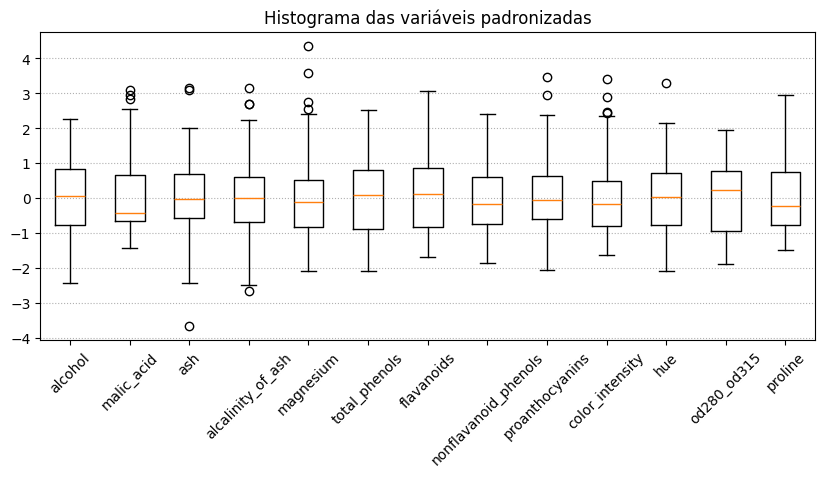

In [8]:
fig, ax = plt.subplots(figsize=(10,4))
ax.boxplot(X_scaled)
ax.set_xticklabels(X_scaled.columns, rotation=45)
ax.grid(axis='y', linestyle=':')
ax.set_title('Histograma das variáveis padronizadas')
plt.show()

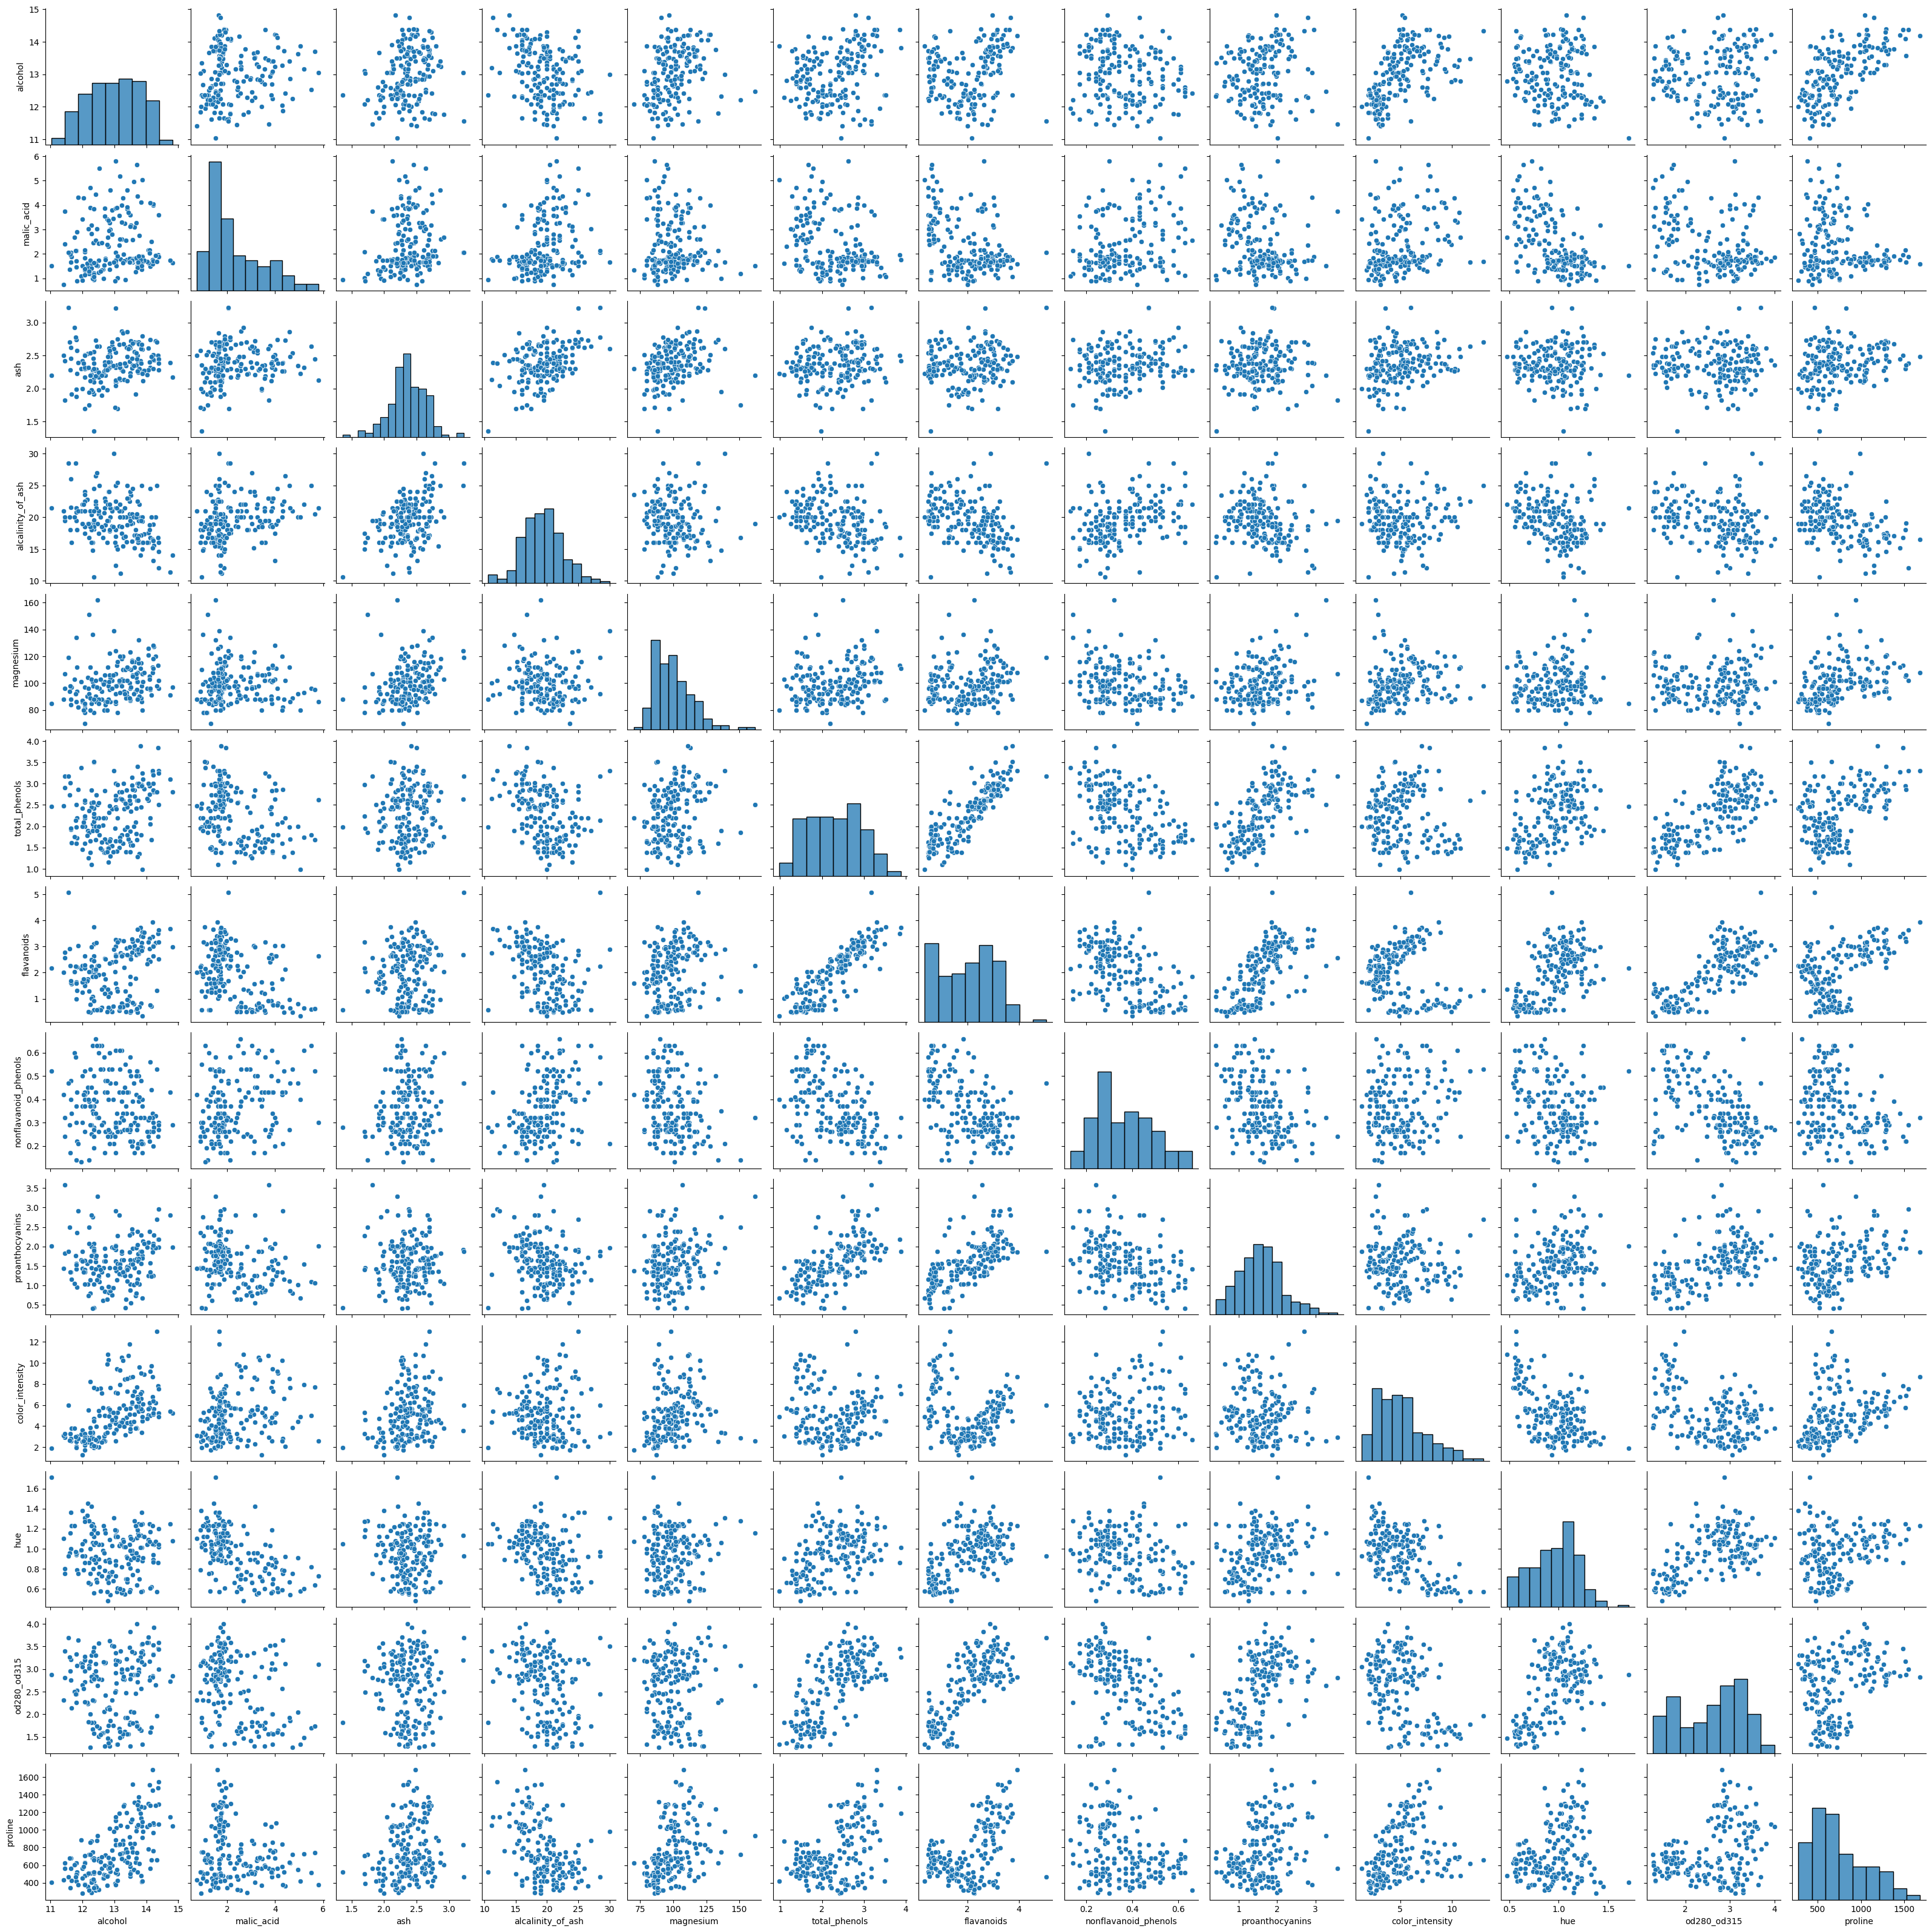

In [149]:
sns.pairplot(data)

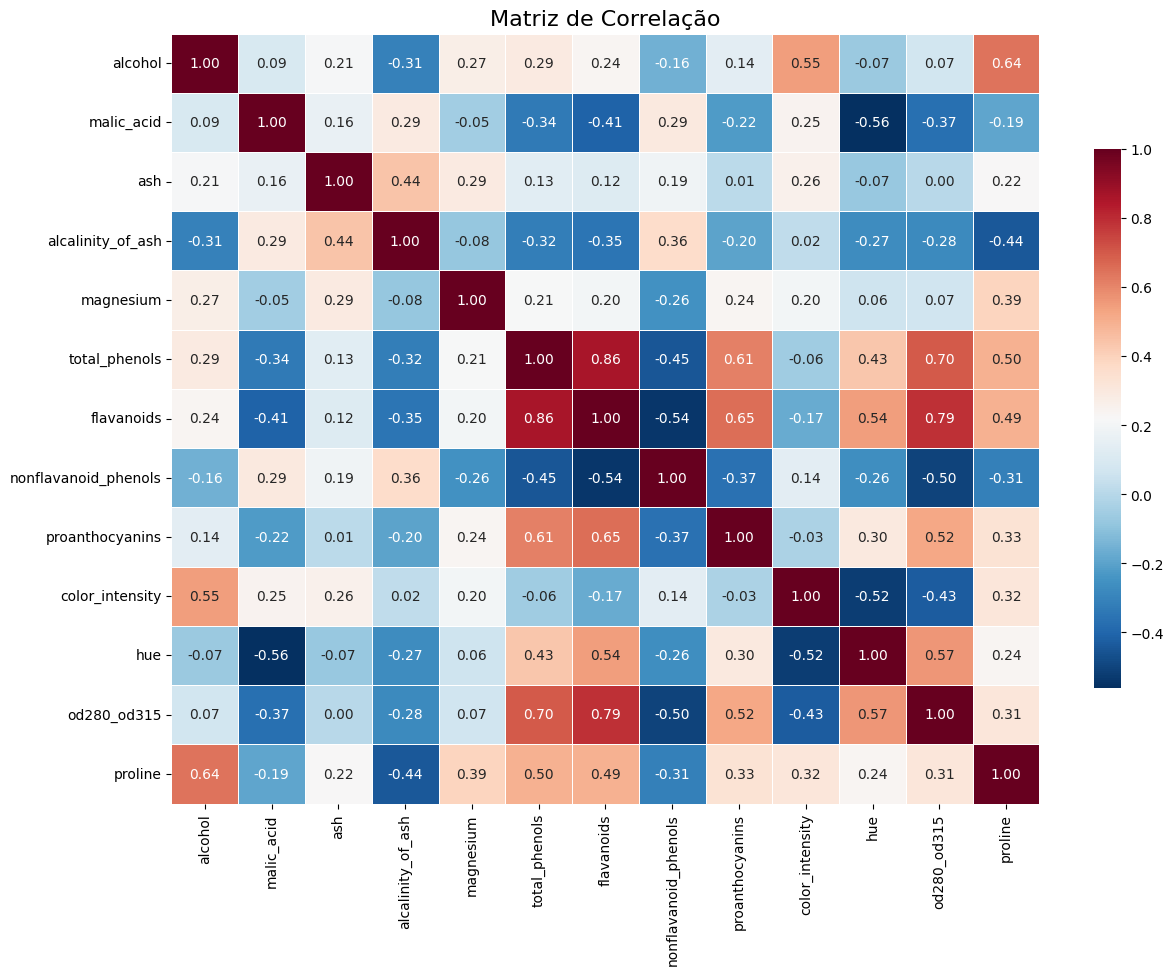

In [9]:
plt.figure(figsize=(14, 10))
sns.heatmap(
    features.corr(),
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    linewidths=.5,
    cbar_kws={"shrink": .7}
)
plt.title("Matriz de Correlação", fontsize=16)
# plt.savefig("C:/Users/aless/Desktop/Codes/masters/Estatística/Multivariada/img/matriz_correlacao.png", dpi=300, bbox_inches='tight')
plt.show()

In [10]:
data_stream = {}
score_stream = {}

data_stream['original'] = X_scaled.copy()

## PCA

In [11]:
pca = PCA()
pca.fit(X_scaled)

P = pca.components_.T # matriz nxn cujas colunas são os componentes principais
Lambda = pca.explained_variance_ # matriz nxn cuja diagonal são os autovalores

Y = pca.transform(X_scaled) # scores
explained = pca.explained_variance_ratio_

In [ ]:
# X_scaled@P[:,:2]

In [14]:
np.cumsum(explained)

array([0.36198848, 0.55406338, 0.66529969, 0.73598999, 0.80162293,
       0.85098116, 0.89336795, 0.92017544, 0.94239698, 0.96169717,
       0.97906553, 0.99204785, 1.        ])

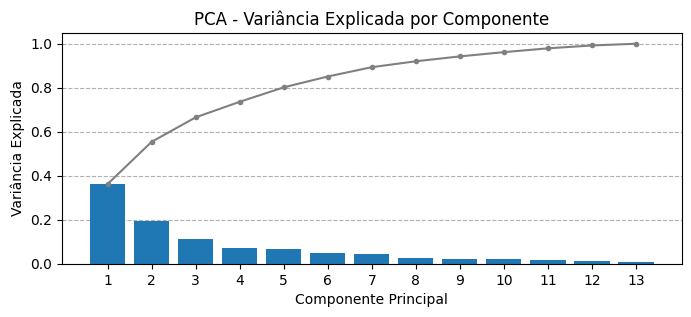

In [12]:
plt.figure(figsize=(8, 3))
plt.bar(range(1, len(explained)+1), explained, zorder=2)
plt.plot(range(1, len(explained)+1), np.cumsum(explained), marker='.', color='gray')

plt.xlabel("Componente Principal")
plt.ylabel("Variância Explicada")
plt.title("PCA - Variância Explicada por Componente")
plt.xticks(range(1, len(explained)+1))
plt.grid(linestyle='--', zorder=0, axis='y')
plt.show()

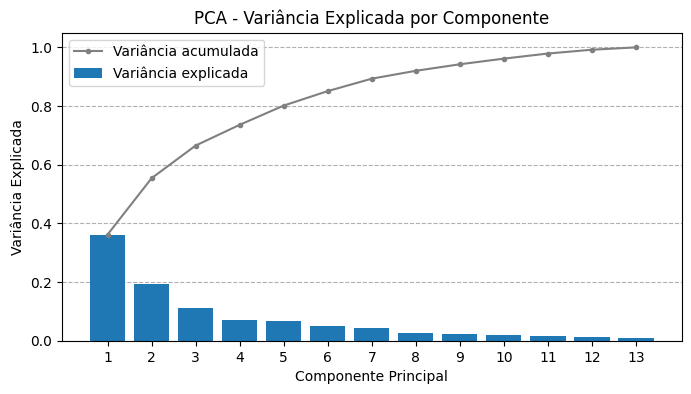

In [12]:
plt.figure(figsize=(8, 4))

plt.bar(
    range(1, len(explained)+1),
    explained,
    zorder=2,
    label="Variância explicada"
)

plt.plot(
    range(1, len(explained)+1),
    np.cumsum(explained),
    marker='.',
    color='gray',
    label="Variância acumulada"
)

plt.xlabel("Componente Principal")
plt.ylabel("Variância Explicada")
plt.title("PCA - Variância Explicada por Componente")
plt.xticks(range(1, len(explained)+1))
plt.grid(linestyle='--', zorder=0, axis='y')

plt.legend()   # ← legenda aqui

plt.show()


In [18]:
n_components=2
pca2 = PCA(n_components)
X_pca2 = pca2.fit_transform(X_scaled)

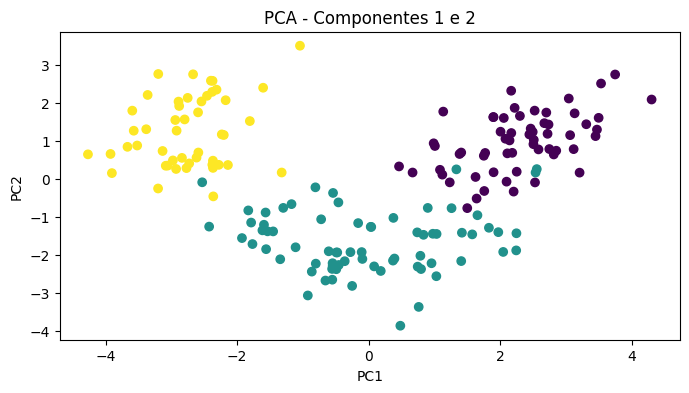

In [19]:
plt.figure(figsize=(8,4))
plt.scatter(X_pca2[:,0], X_pca2[:,1], c=data['class'].astype(int))
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA - Componentes 1 e 2")
plt.show()

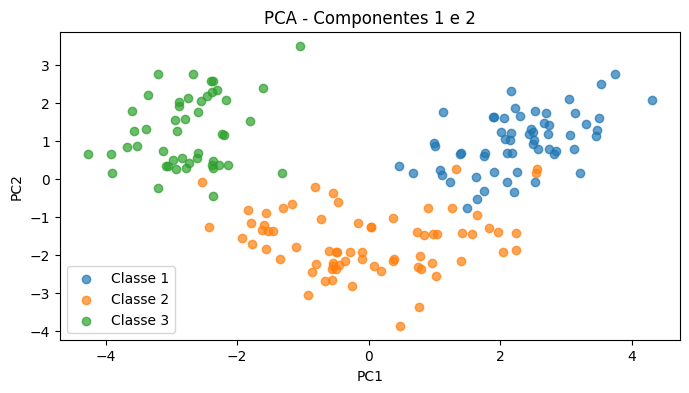

In [15]:
plt.figure(figsize=(8,4))

classes = data['class'].unique()

for cls in classes:
    mask = data['class'] == cls
    plt.scatter(
        X_pca2[mask, 0],
        X_pca2[mask, 1],
        label=f"Classe {cls}",
        alpha=0.7
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA - Componentes 1 e 2")
plt.legend()
plt.show()

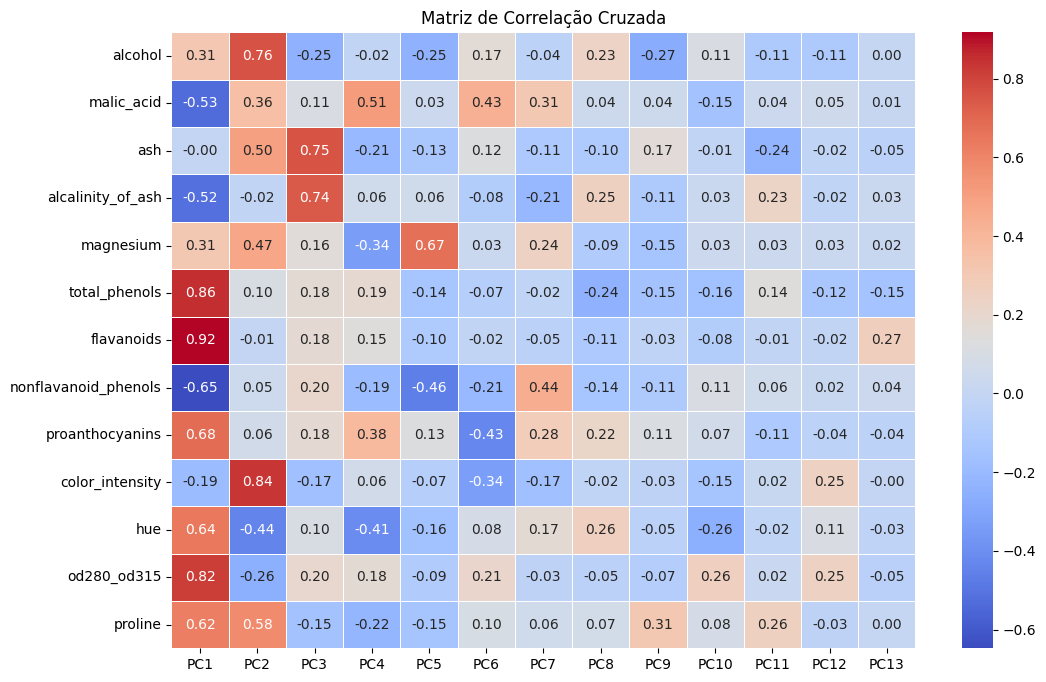

In [20]:
loadings = P * np.sqrt(Lambda)
loading_df = pd.DataFrame(
    loadings,
    index=features.columns,
    columns=[f"PC{i+1}" for i in range(loadings.shape[1])]
)

plt.figure(figsize=(12, 8))
sns.heatmap(
    loading_df,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=.5
)
plt.title("Matriz de Correlação Cruzada")
plt.show()

## Dados com posto incompleto

In [16]:
np.linalg.matrix_rank(features)

np.int64(13)

In [21]:
#Y[:,:n_components]@P[:,:n_components].T
X_singular = pca2.inverse_transform(X_pca2) 
X_singular_scaled = (X_singular-np.mean(X_singular)) / np.std(X_singular)
np.linalg.matrix_rank(X_singular)

np.int64(2)

In [22]:
score_stream['PCA'] = Y[:,:n_components].copy()
data_stream['PCA'] = X_singular.copy()

In [24]:
score_stream.keys()

dict_keys(['PCA'])

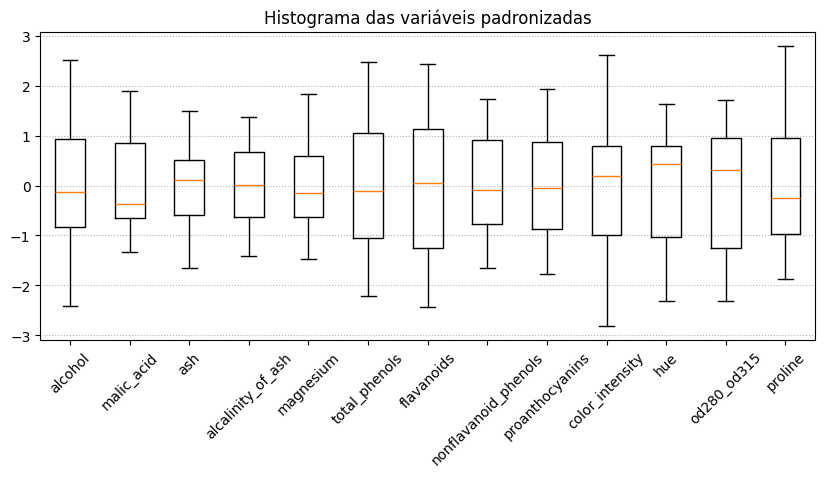

In [23]:
fig, ax = plt.subplots(figsize=(10,4))
ax.boxplot(X_singular_scaled)
ax.set_xticklabels(X_scaled.columns, rotation=45)
ax.grid(axis='y', linestyle=':')
ax.set_title('Histograma das variáveis padronizadas')
plt.show()

# Modelos

## PCA Esparso

In [58]:
spca = SparsePCA(alpha=15, random_state=0)
spca.fit(X_singular_scaled)

P_spca = spca.components_.T # matriz de componentes esparsas
Y_spca = spca.transform(X_singular_scaled) # scores

In [59]:
pd.DataFrame(spca.components_, columns=features.columns).abs().sum().where(lambda x: x > 0).dropna()

total_phenols      1.0
flavanoids         1.0
color_intensity    1.0
od280_od315        1.0
proline            1.0
dtype: float64

In [60]:
df = pd.DataFrame(spca.components_, columns=features.columns).T

def highlight_ones(val):
    if val == 1:
        return "background-color: lightgreen; font-weight: bold;"
    return ""

def zebra_rows(row):
    pos = df.index.get_loc(row.name)
    color = "#ffffff" if pos % 2 == 0 else "#f7f7f7"
    return [f"background-color: {color}"] * len(row)


(df.style
    .apply(zebra_rows, axis=1)            # alternância de linhas
    .map(highlight_ones)             # destaque do valor 1
    .format("{:.0f}")                  # zero casas decimais
)


,0,1,2,3,4,5,6,7,8,9,10,11,12
alcohol,0,0,0,-0,0,0,0,0,0,0,0,0,0
malic_acid,0,0,0,-0,0,0,0,0,0,0,0,0,0
ash,0,0,0,-0,0,0,0,0,0,0,0,0,0
alcalinity_of_ash,0,0,0,-0,0,0,0,0,0,0,0,0,0
magnesium,0,0,0,-0,0,0,0,0,0,0,0,0,0
total_phenols,0,0,0,1,0,0,0,0,0,0,0,0,0
flavanoids,1,0,0,-0,0,0,0,0,0,0,0,0,0
nonflavanoid_phenols,0,0,0,-0,0,0,0,0,0,0,0,0,0
proanthocyanins,0,0,0,-0,0,0,0,0,0,0,0,0,0
color_intensity,0,0,0,-0,0,1,0,0,0,0,0,0,0


In [27]:
spca = SparsePCA(n_components=2, alpha=15, random_state=0)
spca.fit(X_singular_scaled)
Y2_spca = spca.transform(X_singular_scaled) # scores

In [30]:
score_stream['SPCA'] = Y2_spca.copy()

In [28]:
# np.mean((X_singular_scaled - X_recon_spca)**2)

np.float64(0.7281065199779564)

In [29]:
pd.DataFrame(spca.components_, columns=features.columns).round(2).T # autovetores

,0,1
alcohol,0.00,0.0
malic_acid,0.00,0.0
ash,0.00,0.0
alcalinity_of_ash,0.00,0.0
magnesium,0.00,0.0
total_phenols,0.25,0.0
flavanoids,0.97,0.0
nonflavanoid_phenols,0.00,0.0
proanthocyanins,0.00,0.0
color_intensity,0.00,1.0


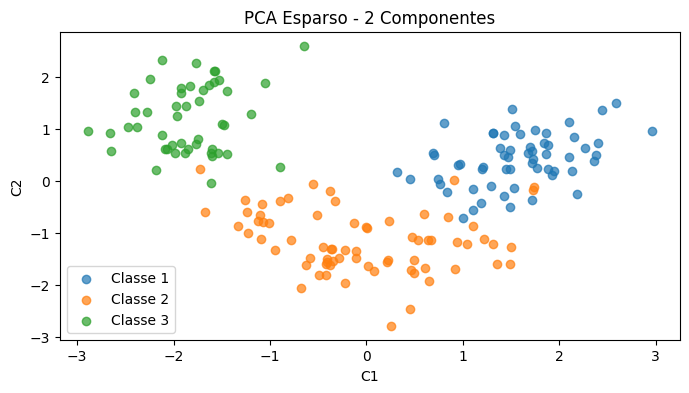

In [32]:
plt.figure(figsize=(8,4))

classes = data['class'].unique()

for cls in classes:
    mask = data['class'] == cls
    plt.scatter(
        Y2_spca[mask, 0],
        Y2_spca[mask, 1],
        label=f"Classe {cls}",
        alpha=0.7
    )

plt.xlabel("C1")
plt.ylabel("C2")
plt.title("PCA Esparso - 2 Componentes")
plt.legend()
plt.show()


In [31]:
spca = SparsePCA(n_components=2, alpha=15, random_state=0)
spca.fit(X_scaled)
Y2_spca = spca.transform(X_scaled) # scores
X_recon_spca = spca.inverse_transform(Y2_spca)

In [32]:
np.mean((X_scaled - X_recon_spca)**2)

np.float64(0.9943820224719101)

In [33]:
data_stream['SPCA'] = X_recon_spca.copy()

## Autoencoder linear

In [34]:
latent_dim = 10
alpha = 0.07

inp = layers.Input(shape=(X_singular_scaled.shape[1],))
encoded = layers.Dense(latent_dim, activation='linear', use_bias=False, 
                       name='enc', kernel_regularizer=regularizers.l1(alpha))(inp)
decoded = layers.Dense(X_singular_scaled.shape[1], activation='linear', use_bias=False, 
                       name='dec', kernel_regularizer=regularizers.l1(alpha))(encoded)

ae_linear = models.Model(inputs=inp, outputs=decoded)
ae_linear.compile(optimizer=optimizers.Adam(learning_rate=1e-2), loss='mse')
ae_linear.summary()

history = ae_linear.fit(X_singular_scaled, X_singular_scaled, epochs=200, batch_size=32, verbose=0)

encoder_linear = models.Model(inputs=inp, outputs=ae_linear.get_layer('enc').output)
Z = encoder_linear.predict(X_singular_scaled)
X_recon = ae_linear.predict(X_singular_scaled)

encoder_weights = ae_linear.get_layer('enc').get_weights()[0]
decoder_weights = ae_linear.get_layer('dec').get_weights()[0]

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 13)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ enc (Dense)                          │ (None, 10)                  │             130 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dec (Dense)                          │ (None, 13)                  │             130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 260 (1.02 KB)

 Trainable params: 260 (1.02 KB)

 Non-trainable params: 0 (0.00 B)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


In [62]:
df = pd.DataFrame(encoder_weights, index=features.columns).round(2)

def highlight_ones(val):
    if val != 0:
        return "background-color: lightgreen; font-weight: bold;"
    return ""

def zebra_rows(row):
    pos = df.index.get_loc(row.name)
    color = "#ffffff" if pos % 2 == 0 else "#f7f7f7"
    return [f"background-color: {color}"] * len(row)


(df.style
    .apply(zebra_rows, axis=1)            # alternância de linhas
    .map(highlight_ones)             # destaque do valor 1
    .format("{:.2f}")                  # zero casas decimais
)


,0,1,2,3,4,5,6,7,8,9
alcohol,-0.00,-0.00,0.00,0.00,-0.00,-0.00,0.00,-0.00,-0.05,-0.00
malic_acid,-0.00,0.00,0.00,-0.00,0.00,-0.00,0.00,0.00,-0.01,0.00
ash,0.00,0.00,0.00,-0.00,0.00,-0.00,-0.00,-0.00,-0.00,0.00
alcalinity_of_ash,0.00,0.00,0.00,0.00,0.00,-0.00,-0.00,0.00,0.00,-0.00
magnesium,0.00,-0.00,0.00,-0.00,-0.00,0.00,-0.00,-0.00,-0.00,0.00
total_phenols,0.00,-0.00,0.00,-0.00,0.00,0.00,0.00,-0.00,-0.00,0.15
flavanoids,0.00,0.00,0.00,-0.00,0.00,0.00,-0.00,0.00,-0.00,2.32
nonflavanoid_phenols,0.00,0.00,-0.00,0.00,0.00,0.00,0.00,0.00,0.00,-0.00
proanthocyanins,0.00,-0.00,-0.00,-0.00,-0.00,0.00,-0.00,0.00,-0.00,0.00
color_intensity,0.00,0.00,-0.00,0.00,-0.00,-0.00,-0.00,-0.00,-1.85,0.00


In [38]:
np.linalg.matrix_rank(encoder_weights.round(2))

np.int64(2)

In [63]:
latent_dim = 2
# alpha = 0.07

inp = layers.Input(shape=(X_singular_scaled.shape[1],))
encoded = layers.Dense(latent_dim, activation='linear', use_bias=False, name='enc')(inp)
decoded = layers.Dense(X_singular_scaled.shape[1], activation='linear', use_bias=False, name='dec')(encoded)

ae_linear = models.Model(inputs=inp, outputs=decoded)
ae_linear.compile(optimizer=optimizers.Adam(learning_rate=1e-2), loss='mse')
ae_linear.summary()

history = ae_linear.fit(X_singular_scaled, X_singular_scaled, epochs=200, batch_size=32, verbose=0)

encoder_linear = models.Model(inputs=inp, outputs=ae_linear.get_layer('enc').output)
Z = encoder_linear.predict(X_singular_scaled)
X_recon = ae_linear.predict(X_singular_scaled)

encoder_weights = ae_linear.get_layer('enc').get_weights()[0]
decoder_weights = ae_linear.get_layer('dec').get_weights()[0]

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 13)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ enc (Dense)                          │ (None, 2)                   │              26 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dec (Dense)                          │ (None, 13)                  │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 52 (208.00 B)

 Trainable params: 52 (208.00 B)

 Non-trainable params: 0 (0.00 B)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


In [65]:
df = pd.DataFrame(encoder_weights, index=features.columns).round(2)
df

,0,1
alcohol,0.32,-0.28
malic_acid,-0.10,-0.38
ash,0.35,1.05
alcalinity_of_ash,0.27,-0.54
magnesium,-0.42,-0.23
total_phenols,-0.62,-0.27
flavanoids,0.06,-0.22
nonflavanoid_phenols,0.60,-0.07
proanthocyanins,-0.42,-0.52
color_intensity,-0.19,0.57


In [69]:
score_stream['AE linear'] = Z.copy()

In [66]:
corr = np.corrcoef(Y[:,:n_components].T, Z.T)   # shape (2k,2k)
k = n_components
corr_cross = corr[:k, k:2*k]     # top-right block: corr(Zp[:,i], Za[:,j])
df_corr = pd.DataFrame(corr_cross, index=[f"PC{i+1}" for i in range(k)], columns=[f"AE{i+1}" for i in range(k)]).round(2)

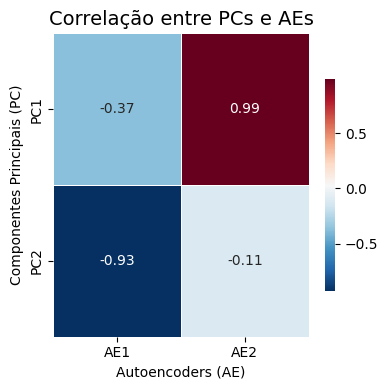

In [76]:
plt.figure(figsize=(4, 4))
sns.heatmap(df_corr, annot=True, fmt=".2f", cmap="RdBu_r", linewidths=.5, cbar_kws={"shrink": .7})

plt.title("Correlação entre PCs e AEs", fontsize=14)
plt.xlabel("Autoencoders (AE)")
plt.ylabel("Componentes Principais (PC)")
plt.tight_layout()
plt.show()

In [70]:
latent_dim = 2
# alpha = 0.07

inp = layers.Input(shape=(X_scaled.shape[1],))
encoded = layers.Dense(latent_dim, activation='linear', use_bias=False, name='enc')(inp)
decoded = layers.Dense(X_scaled.shape[1], activation='linear', use_bias=False, name='dec')(encoded)

ae_linear = models.Model(inputs=inp, outputs=decoded)
ae_linear.compile(optimizer=optimizers.Adam(learning_rate=1e-2), loss='mse')
ae_linear.summary()

history = ae_linear.fit(X_scaled, X_scaled, epochs=200, batch_size=32, verbose=0)

encoder_linear = models.Model(inputs=inp, outputs=ae_linear.get_layer('enc').output)
Z = encoder_linear.predict(X_scaled)
X_recon = ae_linear.predict(X_scaled)

encoder_weights = ae_linear.get_layer('enc').get_weights()[0]
decoder_weights = ae_linear.get_layer('dec').get_weights()[0]

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 13)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ enc (Dense)                          │ (None, 2)                   │              26 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dec (Dense)                          │ (None, 13)                  │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 52 (208.00 B)

 Trainable params: 52 (208.00 B)

 Non-trainable params: 0 (0.00 B)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


In [71]:
np.mean((X_scaled - X_recon)**2)

np.float64(0.4436765086037817)

In [72]:
data_stream['AE linear'] = X_recon.copy()

## Autoencoder não Linear

In [181]:
latent_dim = 2

inp = layers.Input(shape=(X_singular_scaled.shape[1],))
encoded = layers.Dense(latent_dim, activation='sigmoid', use_bias=True, name='enc')(inp)
decoded = layers.Dense(X_singular_scaled.shape[1], activation='sigmoid', use_bias=True, name='dec')(encoded)

ae_linear = models.Model(inputs=inp, outputs=decoded)
ae_linear.compile(optimizer=optimizers.Adam(learning_rate=1e-2), loss='mse')
ae_linear.summary()

history = ae_linear.fit(X_singular_scaled, X_singular_scaled, epochs=200, batch_size=32, verbose=0)

encoder_linear = models.Model(inputs=inp, outputs=ae_linear.get_layer('enc').output)
Z = encoder_linear.predict(X_singular_scaled)
X_recon = ae_linear.predict(X_singular_scaled)

encoder_weights = ae_linear.get_layer('enc').get_weights()[0]
decoder_weights = ae_linear.get_layer('dec').get_weights()[0]

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)           │ (None, 13)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ enc (Dense)                          │ (None, 2)                   │              28 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dec (Dense)                          │ (None, 13)                  │              39 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 67 (268.00 B)

 Trainable params: 67 (268.00 B)

 Non-trainable params: 0 (0.00 B)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


In [182]:
df = pd.DataFrame(encoder_weights, index=features.columns).round(2)
df

,0,1
alcohol,-0.49,-0.55
malic_acid,0.04,-0.25
ash,-0.77,-1.05
alcalinity_of_ash,-0.76,0.50
magnesium,0.39,-0.68
total_phenols,0.47,-0.77
flavanoids,0.66,-0.84
nonflavanoid_phenols,-0.42,0.11
proanthocyanins,0.32,-0.97
color_intensity,-0.48,-0.51


In [183]:
score_stream['AE não linear'] = Z.copy()
Z.shape

(178, 2)

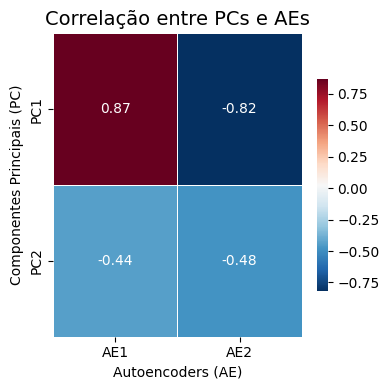

In [184]:
corr = np.corrcoef(Y[:,:n_components].T, Z.T)   # shape (2k,2k)
k = n_components
corr_cross = corr[:k, k:2*k]     # top-right block: corr(Zp[:,i], Za[:,j])
df_corr = pd.DataFrame(corr_cross, index=[f"PC{i+1}" for i in range(k)], columns=[f"AE{i+1}" for i in range(k)]).round(2)

plt.figure(figsize=(4, 4))
sns.heatmap(df_corr, annot=True, fmt=".2f", cmap="RdBu_r", linewidths=.5, cbar_kws={"shrink": .7})

plt.title("Correlação entre PCs e AEs", fontsize=14)
plt.xlabel("Autoencoders (AE)")
plt.ylabel("Componentes Principais (PC)")
plt.tight_layout()
plt.show()

In [189]:
latent_dim = 2

inp = layers.Input(shape=(X_scaled.shape[1],))
encoded = layers.Dense(latent_dim, activation='sigmoid', use_bias=True, name='enc')(inp)
decoded = layers.Dense(X_scaled.shape[1], activation='sigmoid', use_bias=True, name='dec')(encoded)

ae_linear = models.Model(inputs=inp, outputs=decoded)
ae_linear.compile(optimizer=optimizers.Adam(learning_rate=1e-2), loss='mse')
ae_linear.summary()

history = ae_linear.fit(X_scaled, X_scaled, epochs=200, batch_size=32, verbose=0)

encoder_linear = models.Model(inputs=inp, outputs=ae_linear.get_layer('enc').output)
Z = encoder_linear.predict(X_scaled)
X_recon = ae_linear.predict(X_scaled)

encoder_weights = ae_linear.get_layer('enc').get_weights()[0]
decoder_weights = ae_linear.get_layer('dec').get_weights()[0]

Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)           │ (None, 13)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ enc (Dense)                          │ (None, 2)                   │              28 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dec (Dense)                          │ (None, 13)                  │              39 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 67 (268.00 B)

 Trainable params: 67 (268.00 B)

 Non-trainable params: 0 (0.00 B)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


In [190]:
np.mean((X_scaled - X_recon)**2)

np.float64(0.7636757669630054)

In [191]:
data_stream['AE não linear'] = X_recon.copy()

In [194]:
score_stream['AE linear'] = score_stream.pop('AE')
data_stream['AE linear'] = data_stream.pop('AE')

## Factor Analysis

In [107]:
fa = FactorAnalysis(random_state=0) #n_components=2,
Z_fa = fa.fit_transform(X_singular_scaled)

loadings = fa.components_.T     # shape: (13, 2)
psi = fa.noise_variance_        # uniquenesses, shape: (13,)

In [108]:
pd.DataFrame(loadings, index=features.columns).round(2)

,0,1,2,3,4,5,6,7,8,9,10,11,12
alcohol,-0.38,-1.04,-0.0,0.0,-0.0,-0.0,0.0,0.0,0.0,-0.0,-0.0,-0.0,0.0
malic_acid,0.73,-0.45,-0.0,-0.0,0.0,0.0,-0.0,-0.0,0.0,-0.0,-0.0,0.0,0.0
ash,0.03,-0.67,0.0,0.0,0.0,0.0,-0.0,0.0,-0.0,0.0,-0.0,0.0,-0.0
alcalinity_of_ash,0.70,0.05,-0.0,-0.0,0.0,-0.0,0.0,0.0,-0.0,-0.0,-0.0,-0.0,0.0
magnesium,-0.39,-0.65,-0.0,0.0,0.0,0.0,0.0,-0.0,0.0,0.0,-0.0,-0.0,-0.0
total_phenols,-1.14,-0.19,-0.0,-0.0,-0.0,-0.0,0.0,0.0,-0.0,-0.0,0.0,0.0,0.0
flavanoids,-1.23,-0.04,0.0,-0.0,0.0,-0.0,-0.0,-0.0,0.0,0.0,-0.0,0.0,0.0
nonflavanoid_phenols,0.87,-0.02,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,0.0,-0.0,-0.0,-0.0
proanthocyanins,-0.91,-0.12,-0.0,-0.0,-0.0,0.0,-0.0,0.0,0.0,0.0,0.0,-0.0,-0.0
color_intensity,0.30,-1.11,-0.0,0.0,0.0,-0.0,0.0,-0.0,-0.0,0.0,0.0,0.0,0.0


In [109]:
pd.DataFrame(psi).T.round(2)

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,0.01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.01,0.0,0.0,0.01


In [168]:
fa = FactorAnalysis(n_components=2, random_state=0)
Z_fa = fa.fit_transform(X_singular_scaled)

loadings = fa.components_.T     # shape: (13, 2)
psi = fa.noise_variance_        # uniquenesses, shape: (13,)

score_stream['FA'] = Z_fa.copy()
Z_fa.shape

(178, 2)

In [169]:
pd.DataFrame(loadings, index=features.columns).round(2).T

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280_od315,proline
0,0.42,-0.71,-0.01,-0.70,0.41,1.15,1.23,-0.87,0.91,-0.26,0.86,1.10,0.84
1,-1.03,-0.48,-0.67,0.02,-0.64,-0.14,0.01,-0.06,-0.08,-1.13,0.59,0.35,-0.77


In [173]:
pd.DataFrame(psi, index=features.columns)[0].round(4)

alcohol                 0.0
malic_acid              0.0
ash                     0.0
alcalinity_of_ash       0.0
magnesium               0.0
total_phenols           0.0
flavanoids              0.0
nonflavanoid_phenols    0.0
proanthocyanins         0.0
color_intensity         0.0
hue                     0.0
od280_od315             0.0
proline                 0.0
Name: 0, dtype: float64

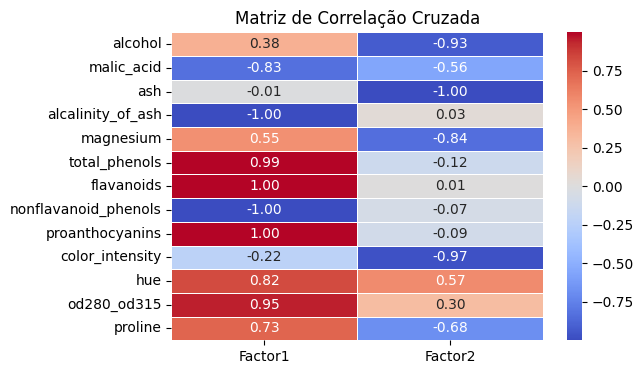

In [162]:
p = X_scaled.shape[1]
k = Z_fa.shape[1]

corr_vars_factors = np.zeros((p, k))
for j in range(p):
    for i in range(k):
        corr_vars_factors[j, i] = np.corrcoef(X_singular_scaled[:, j], Z_fa[:, i])[0, 1]

corr_df = pd.DataFrame(
    corr_vars_factors,
    columns=[f"Factor{i+1}" for i in range(k)],
    index=features.columns
)

plt.figure(figsize=(6, 4))
sns.heatmap(
    corr_df,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=.5
)
plt.title("Matriz de Correlação Cruzada")
plt.show()

In [163]:
fa = FactorAnalysis(n_components=2, random_state=0)
Z_fa = fa.fit_transform(X_scaled)

loadings = fa.components_.T     # shape: (13, 2)
psi = fa.noise_variance_        # uniquenesses, shape: (13,)
X_hat = Z_fa @ loadings.T

In [149]:
data_stream['FA'] = X_hat.copy()

In [164]:
pd.DataFrame(loadings, index=features.columns).round(2)

,0,1
alcohol,0.23,0.70
malic_acid,-0.44,0.21
ash,0.07,0.32
alcalinity_of_ash,-0.38,-0.11
magnesium,0.21,0.32
total_phenols,0.88,0.16
flavanoids,0.96,0.05
nonflavanoid_phenols,-0.56,0.00
proanthocyanins,0.66,0.11
color_intensity,-0.23,0.87


In [165]:
pd.DataFrame(psi).T.round(4)

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,0.4495,0.7565,0.889,0.8356,0.8478,0.1972,0.0791,0.6816,0.5532,0.187,0.4942,0.2417,0.4556


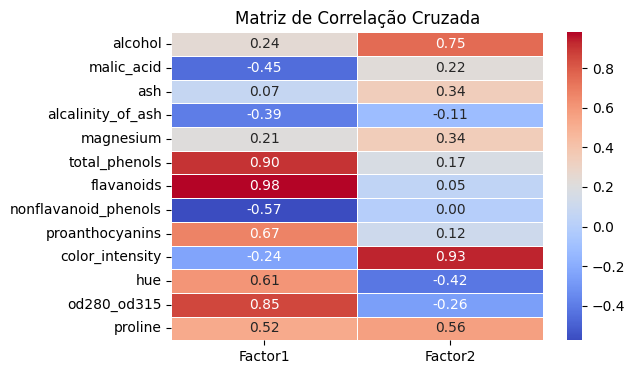

In [166]:
p = X_scaled.shape[1]
k = Z_fa.shape[1]

corr_vars_factors = np.zeros((p, k))
for j in range(p):
    for i in range(k):
        corr_vars_factors[j, i] = np.corrcoef(X_scaled.iloc[:, j], Z_fa[:, i])[0, 1]

corr_df = pd.DataFrame(
    corr_vars_factors,
    columns=[f"Factor{i+1}" for i in range(k)],
    index=features.columns
)

plt.figure(figsize=(6, 4))
sns.heatmap(
    corr_df,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=.5
)
plt.title("Matriz de Correlação Cruzada")
plt.show()

# Resultados

## MSE

In [248]:
mse = pd.DataFrame({
    'Modelo': list(data_stream.keys()),
    'MSE': [np.mean((data_stream['original'] - data_stream[key])**2) for key in data_stream.keys()]
}).loc[1:,:].round(4).sort_values(by='MSE').reset_index()[['Modelo','MSE']]
mse

,Modelo,MSE
0,PCA,0.4434
1,AE linear,0.4437
2,FA,0.4786
3,AE não linear,0.7637
4,SPCA,0.9944


## Pairplot

In [199]:
dfs = []

for model_name, df in score_stream.items():
    df_renamed = pd.DataFrame(df)
    df_renamed.columns = [f"{model_name}_componente{i+1}" for i in range(df.shape[1])]
    dfs.append(df_renamed)

df_plot = pd.concat(dfs, axis=1)
df_plot["class"] = data["class"].values
df_plot

,PCA_componente1,PCA_componente2,SPCA_componente1,SPCA_componente2,FA_componente1,FA_componente2,AE não linear_componente1,AE não linear_componente2,AE linear_componente1,AE linear_componente2,class
0,3.307421,1.439402,2.271552,0.626644,1.528952,-0.913479,0.965959,0.001377,-3.135678,-0.057362,1
1,2.203250,-0.332455,1.490416,-0.495469,1.018516,0.210984,0.977348,0.157534,-1.740674,-1.110541,1
2,2.509661,1.028251,1.722518,0.430276,1.160164,-0.652552,0.939541,0.011600,-2.362097,-0.096642,1
3,3.746497,2.748618,2.592842,1.500305,1.731928,-1.744339,0.927531,0.000074,-3.853428,0.863534,1
4,1.006070,0.867384,0.698554,0.494282,0.465085,-0.550463,0.724949,0.197329,-1.069642,0.339246,1
...,...,...,...,...,...,...,...,...,...,...,...
173,-3.361043,2.210055,-2.243570,1.959713,-1.553740,-1.402553,0.002309,0.989056,2.196247,3.108233,3
174,-2.594637,1.752286,-1.731162,1.545496,-1.199446,-1.112043,0.009929,0.978683,1.682993,2.437824,3
175,-2.670307,2.753133,-1.764891,2.261999,-1.234427,-1.747204,0.003197,0.912731,1.476004,3.297602,3
176,-2.380303,2.290884,-1.576099,1.900928,-1.100364,-1.453850,0.007492,0.928162,1.359721,2.803907,3


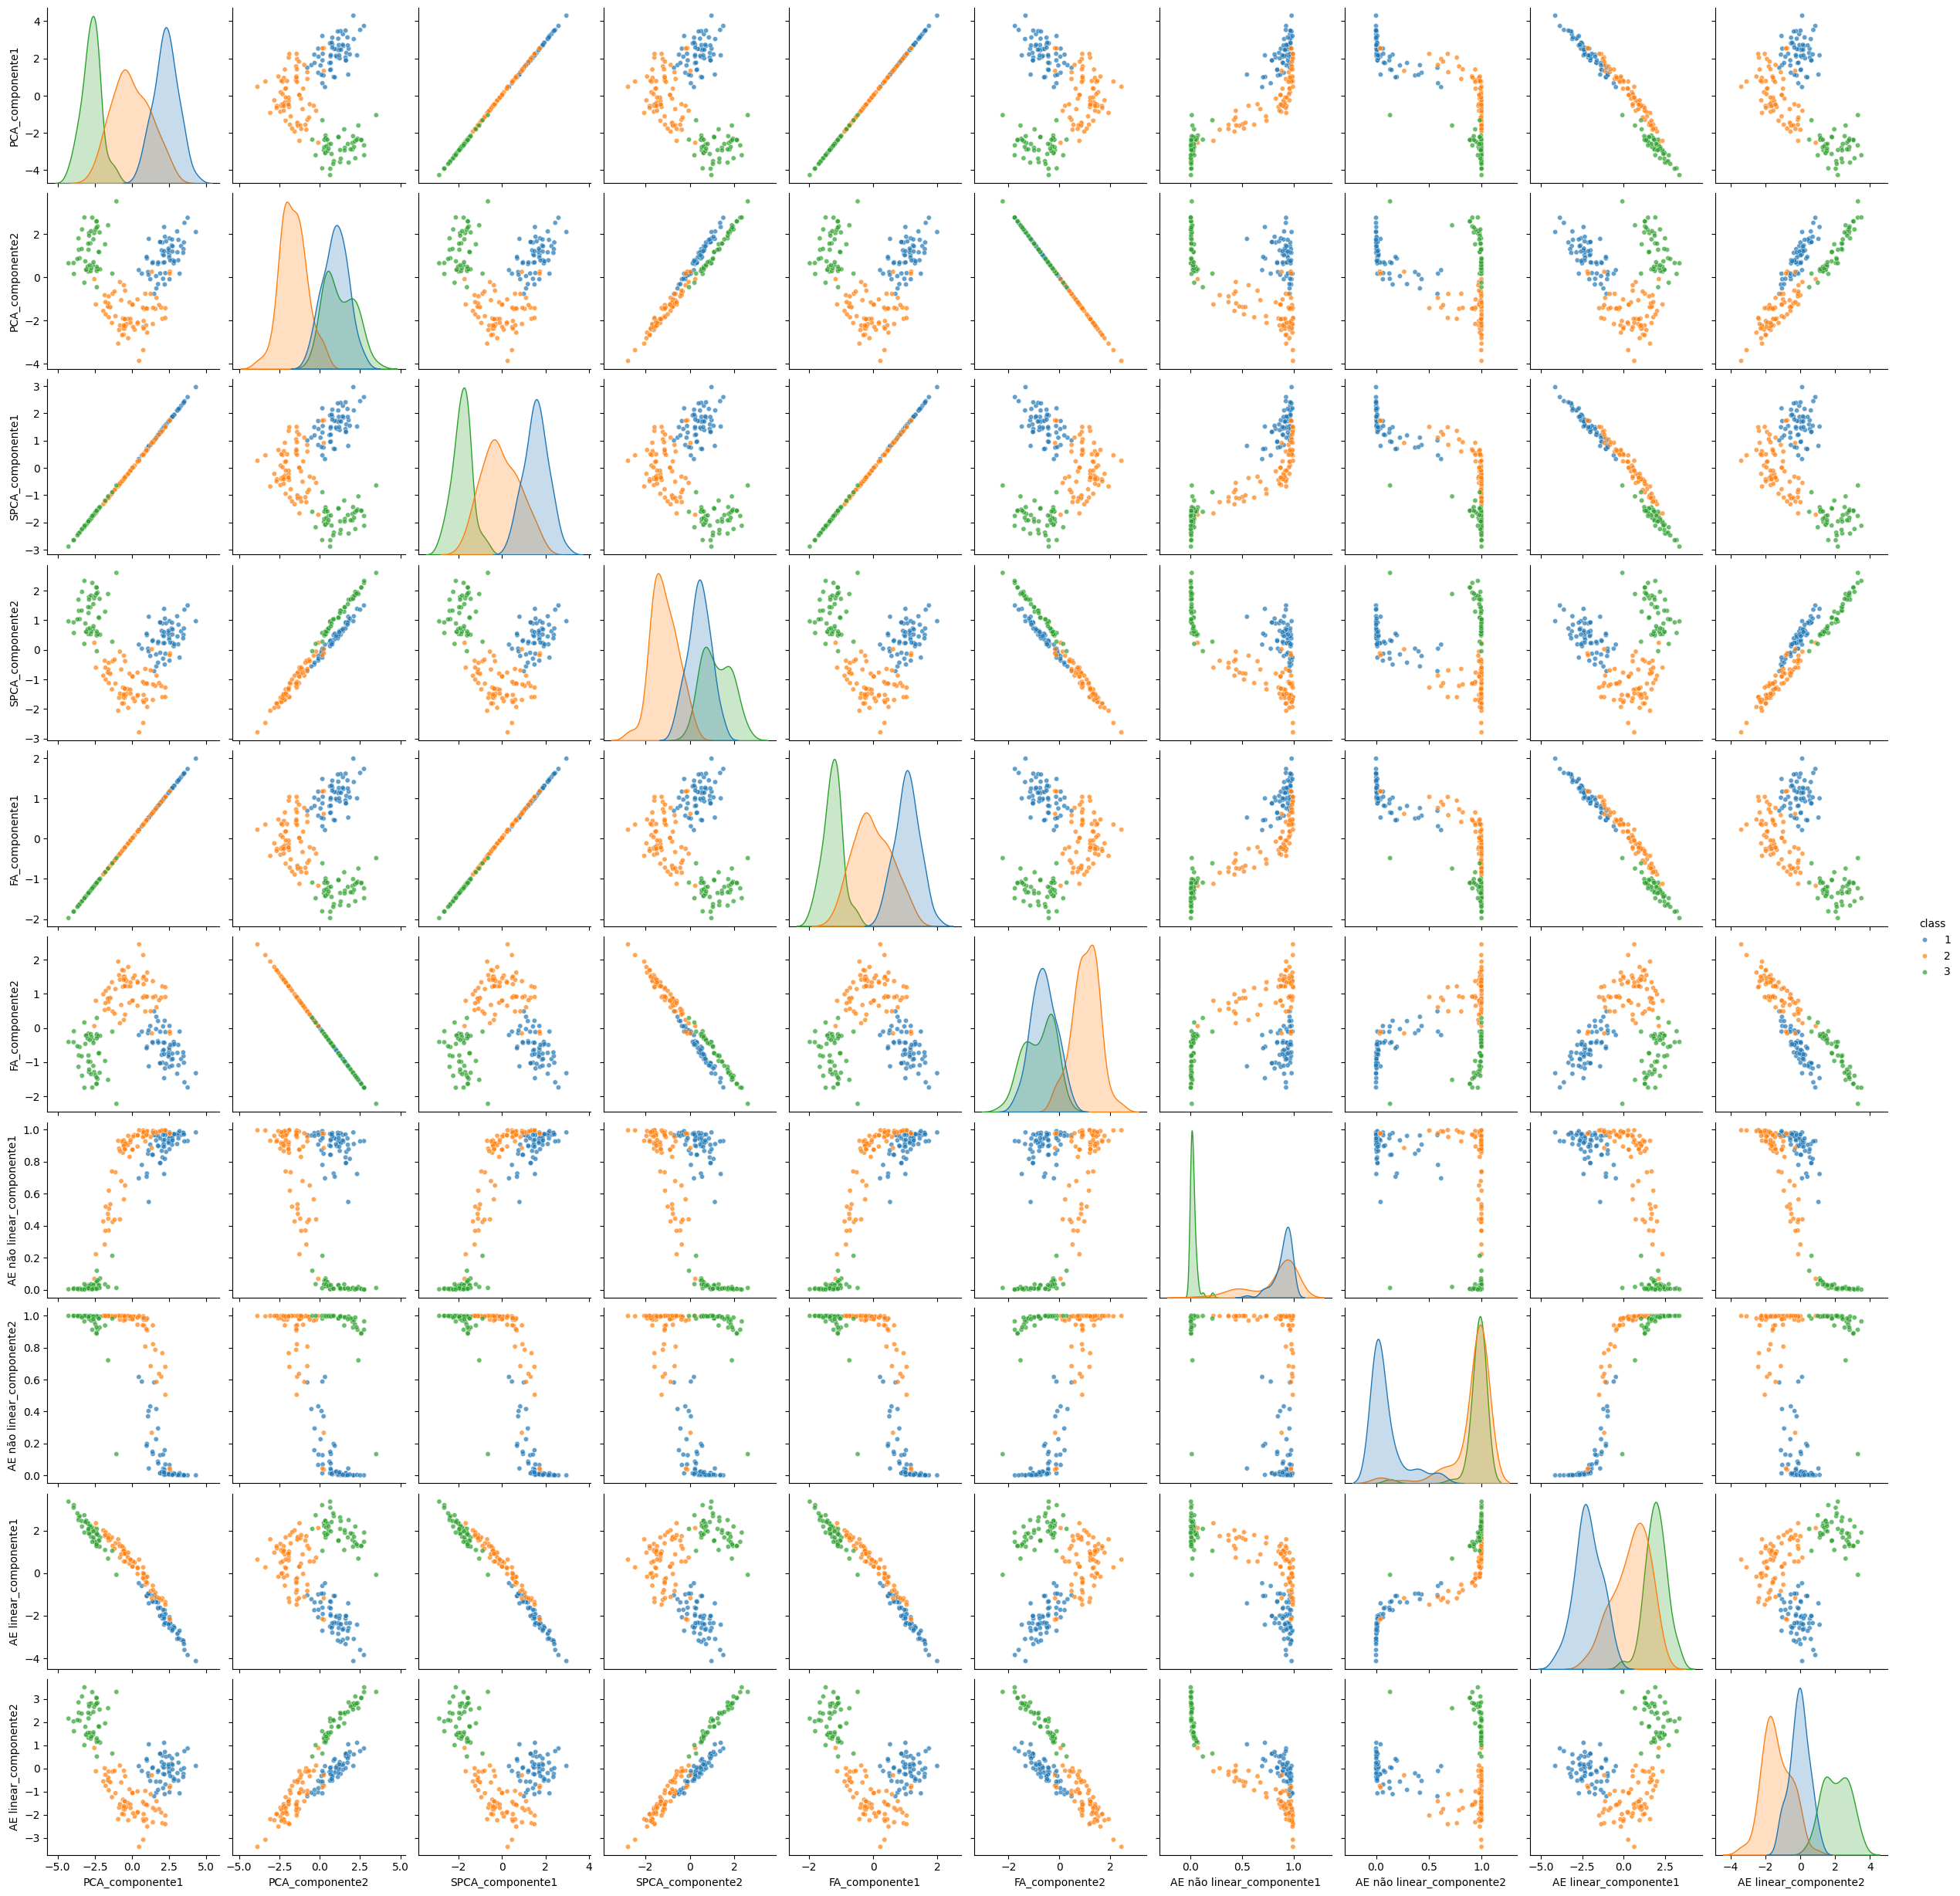

In [200]:
sns.pairplot(
    df_plot,
    hue="class",
    diag_kind="kde",      # ou "hist"
    plot_kws={"s": 20, "alpha": 0.7}  # tamanho e transparência dos pontos
)
plt.show()

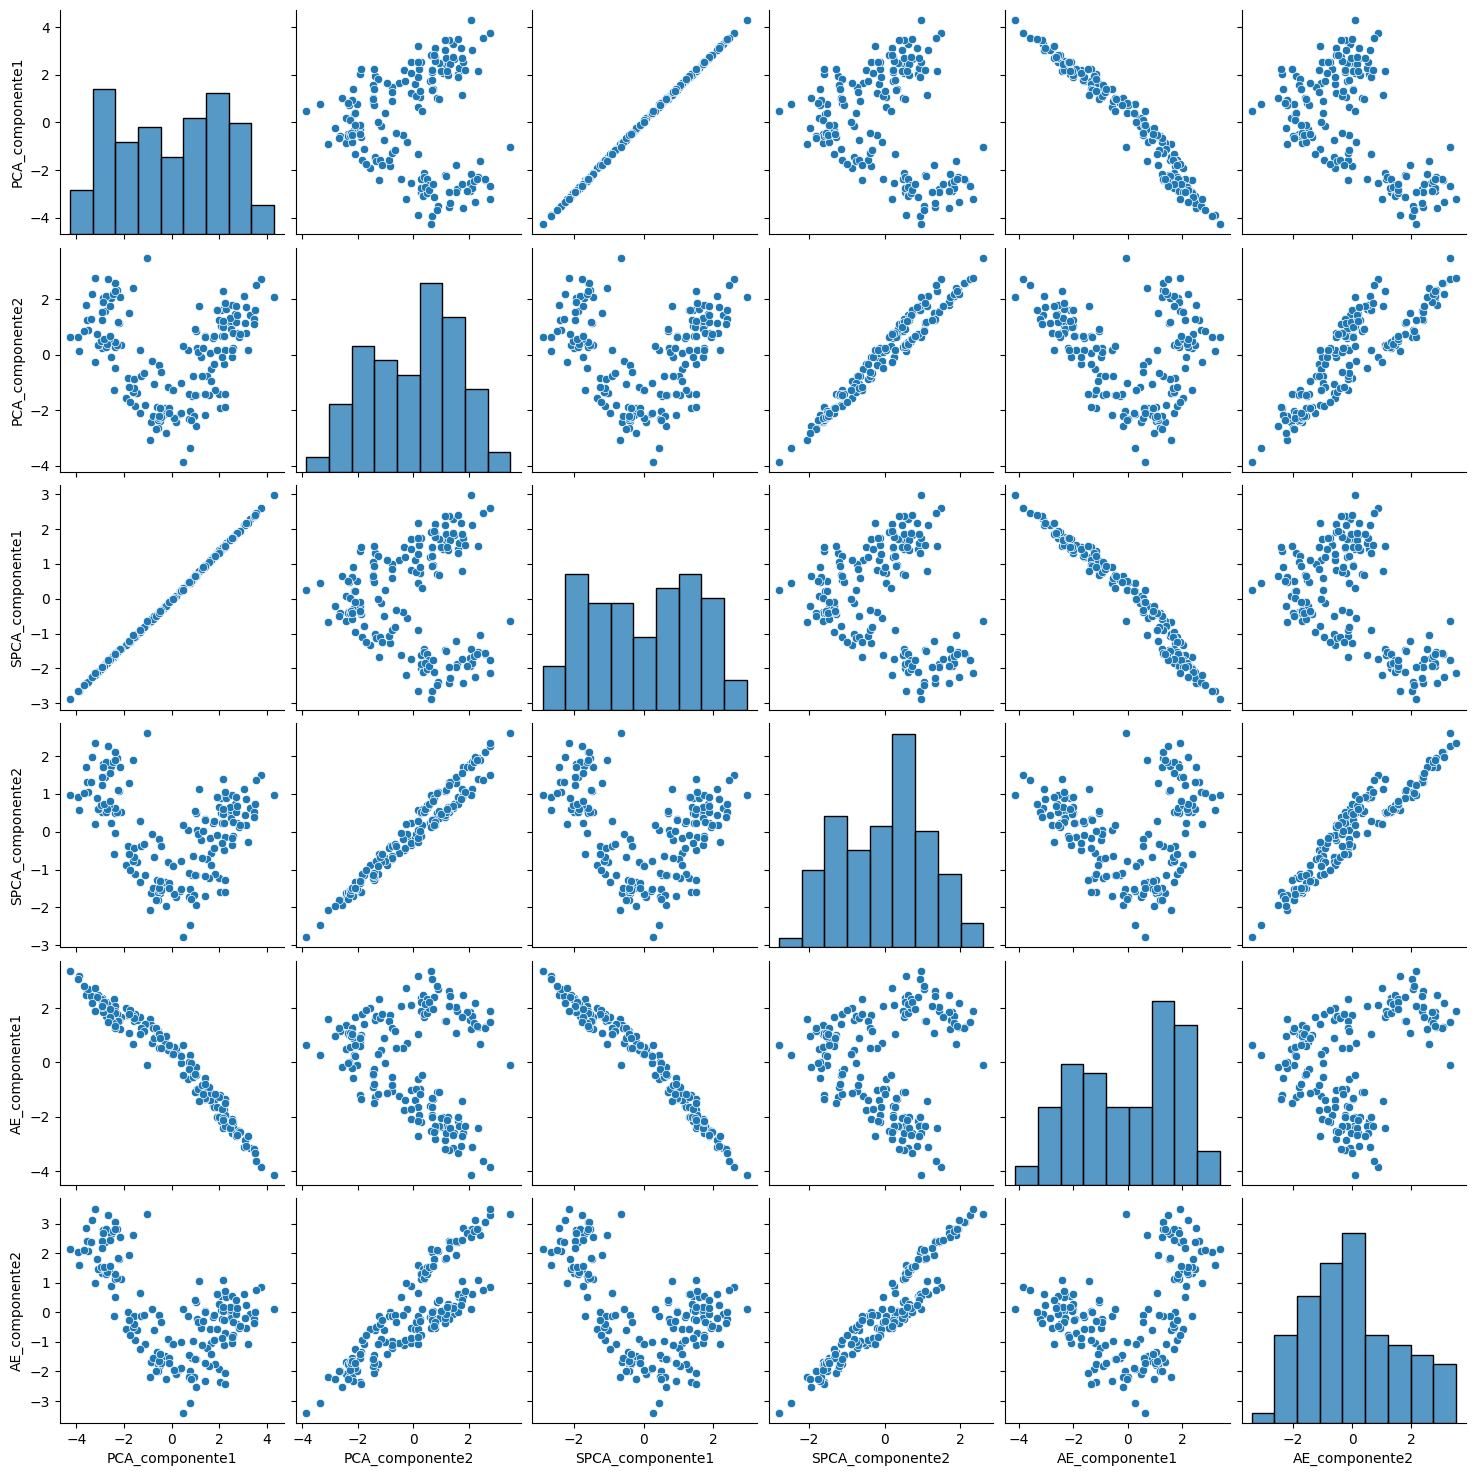

In [85]:
sns.pairplot(df_final)

## Classificação

In [236]:
y = data['class']
lda = LinearDiscriminantAnalysis()
lda.fit(X_scaled, y)

y_pred = lda.predict(X_scaled)
Z_lda = lda.transform(X_scaled)
acc = accuracy_score(y, y_pred)

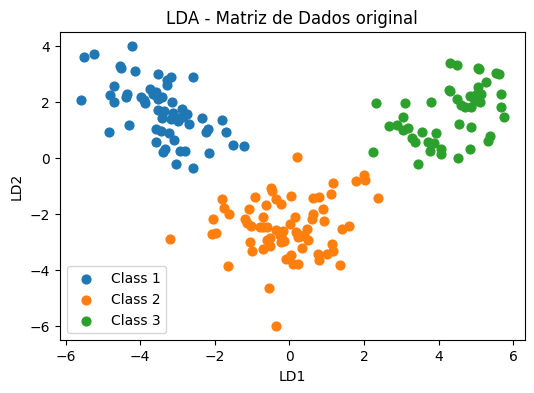

In [238]:
plt.figure(figsize=(6,4))
classes = np.unique(y)

for c in classes:
    idx = (y == c)
    plt.scatter(Z_lda[idx, 0], Z_lda[idx, 1], label=f"Class {c}", s=40)

plt.xlabel("LD1")
plt.ylabel("LD2")
plt.title("LDA - Matriz de Dados original")
plt.legend()
# plt.grid(True)
plt.show()

In [ ]:
acuracia = pd.DataFrame({
    'Modelo': list(data_stream.keys()),
    'Acurácia': [0.0]*len(data_stream.keys())
})
acuracia.loc[acuracia['Modelo'] == 'original', 'Acurácia'] = acc

y = data['class']
lda = LinearDiscriminantAnalysis()

for model_name, X in score_stream.items():
    
    lda.fit(X, y)
    y_pred = lda.predict(X)
    Z_lda = lda.transform(X)
    acc = accuracy_score(y, y_pred)
    acuracia.loc[acuracia['Modelo'] == model_name, 'Acurácia'] = acc

In [246]:
(acuracia['Acurácia']-1)*100

0    0.000000
1   -2.808989
2   -2.808989
3   -2.808989
4   -6.179775
5   -2.808989
Name: Acurácia, dtype: float64

In [249]:
mse

,Modelo,MSE
0,PCA,0.4434
1,AE linear,0.4437
2,FA,0.4786
3,AE não linear,0.7637
4,SPCA,0.9944


In [244]:
acuracia.round(5).sort_values(by='Acurácia', ascending=False).reset_index()[['Modelo','Acurácia']]

,Modelo,Acurácia
0,original,1.00000
1,PCA,0.97191
2,SPCA,0.97191
3,FA,0.97191
4,AE linear,0.97191
5,AE não linear,0.93820
